In [1]:
import networkx as nx 
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from skimage.morphology import skeletonize
from skimage.util import img_as_ubyte
from skimage.measure import label
from scipy.ndimage import distance_transform_edt
from sklearn.decomposition import PCA
from collections import defaultdict

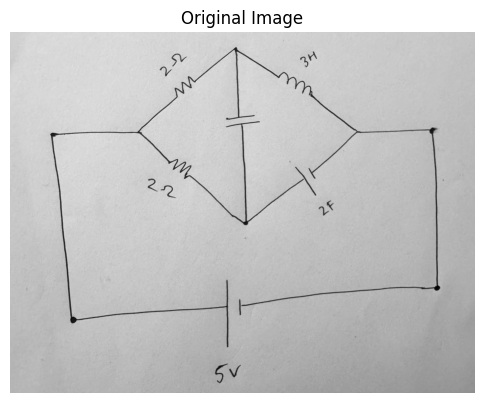

In [28]:
img_path = "/Users/mac/Downloads/LineDetect/ImageData/IMG_7528.jpg"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Image not found at {img_path}")

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

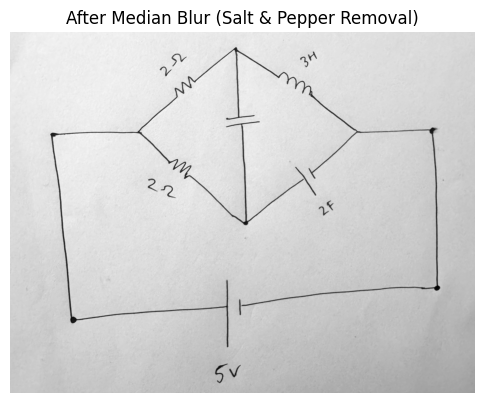

In [3]:
denoised = cv2.medianBlur(img, 5)

plt.figure(figsize=(6,6))
plt.imshow(denoised, cmap="gray")
plt.title("After Median Blur (Salt & Pepper Removal)")
plt.axis("off")
plt.show()


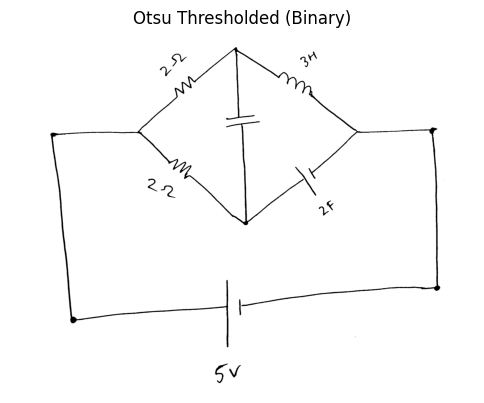

Otsu thresholded image saved at /Users/mac/Downloads/LineDetect/ImageData/otsu_thresholded.png


In [4]:
_, otsu_bin = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(6,6))
plt.imshow(otsu_bin, cmap="gray")
plt.title("Otsu Thresholded (Binary)")
plt.axis("off")
plt.show()

imsave_path = "/Users/mac/Downloads/LineDetect/ImageData/otsu_thresholded.png"
cv2.imwrite(imsave_path, otsu_bin)
print(f"Otsu thresholded image saved at {imsave_path}")

In [5]:
img_path = "/Users/mac/Downloads/LineDetect/ImageData/otsu_thresholded.png"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
otsu_bin = img

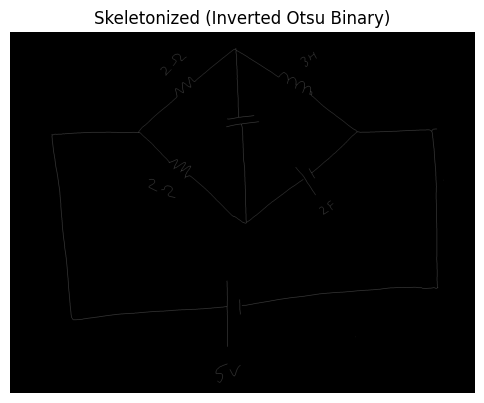

In [6]:
inverted = cv2.bitwise_not(otsu_bin)

# ensure binary is boolean
binary_bool = inverted > 0

# skeletonize
skeleton = skeletonize(binary_bool)

plt.figure(figsize=(6,6))
plt.imshow(skeleton, cmap="gray")
plt.title("Skeletonized (Inverted Otsu Binary)")
plt.axis("off")
plt.show()

In [7]:
label_path = "/Users/mac/Downloads/LineDetect/ImageData/otsu_thresholded.txt"
img = otsu_bin
h, w = img.shape

with open(label_path, "r") as f:
    yolo_lines = [ln.strip() for ln in f.readlines() if ln.strip()]



Found 19 bounding boxes


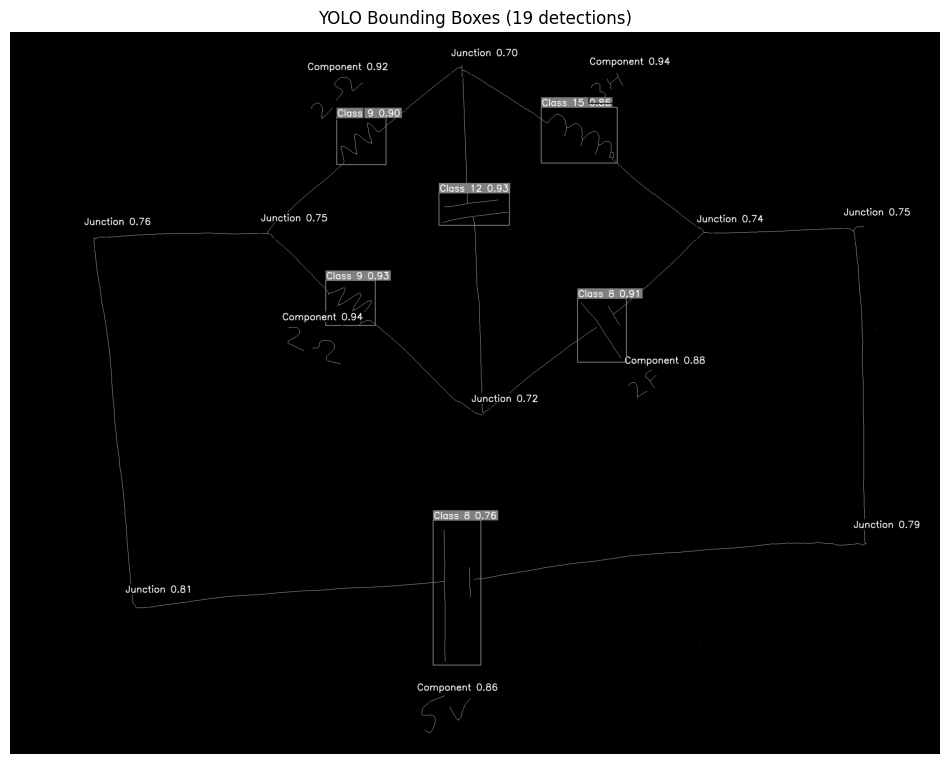


Detections by class:
  Component (class 0): 5
  Junction (class 1): 8
  Class 8 (class 8): 2
  Class 9 (class 9): 2
  Class 12 (class 12): 1
  Class 15 (class 15): 1


In [8]:
# ---------------- Draw YOLO bounding boxes on image ----------------
label_path = "/Users/mac/Downloads/LineDetect/ImageData/otsu_thresholded.txt"

# Read the image and convert to BGR for colored bounding boxes
# vis_img = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2BGR)
vis_img = skeleton.astype(np.uint8) * 255
img_h, img_w = skeleton.shape
# vis_img=img.copy()

# Define colors for different classes (BGR format)
class_colors = {
    0: (0, 0, 255),    # Green for class 0
    1: (0, 0, 255),    # Red for class 1
    2: (255, 0, 0),    # Blue for class 2
    3: (255, 255, 0),  # Cyan for class 3
    4: (255, 0, 255),  # Magenta for class 4
}

class_names = {
    0: "Component",
    1: "Junction",
    2: "Line",
}

# Read YOLO labels and draw boxes
with open(label_path, "r") as f:
    lines = [ln.strip() for ln in f.readlines() if ln.strip()]

print(f"Found {len(lines)} bounding boxes")

for line in lines:
    parts = line.split()
    if len(parts) < 5:
        continue
    
    class_id = int(parts[0])
    x_center = float(parts[1])
    y_center = float(parts[2])
    box_w = float(parts[3])
    box_h = float(parts[4])
    conf = float(parts[5]) if len(parts) > 5 else None
    
    # Convert normalized coords to pixel coords
    x1 = int((x_center - box_w / 2) * img_w)
    y1 = int((y_center - box_h / 2) * img_h)
    x2 = int((x_center + box_w / 2) * img_w)
    y2 = int((y_center + box_h / 2) * img_h)
    
    # Clip to image bounds
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img_w, x2), min(img_h, y2)
    
    # Get color for this class
    color = class_colors.get(class_id, (128, 128, 128))
    
    # Draw rectangle
    cv2.rectangle(vis_img, (x1, y1), (x2, y2), color, 2)
    
    # Draw label
    label = class_names.get(class_id, f"Class {class_id}")
    if conf is not None:
        label = f"{label} {conf:.2f}"
    
    # Label background (larger font size: 1.0 instead of 0.5, thickness: 2 instead of 1)
    font_scale = 1.0
    font_thickness = 2
    (label_w, label_h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_thickness)
    cv2.rectangle(vis_img, (x1, y1 - label_h - 10), (x1 + label_w + 5, y1), color, -1)
    cv2.putText(vis_img, label, (x1 + 2, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), font_thickness)

# Display
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.title(f"YOLO Bounding Boxes ({len(lines)} detections)")
plt.axis("off")
plt.show()

# Count by class
from collections import Counter
class_counts = Counter(int(line.split()[0]) for line in lines if line.split())
print("\nDetections by class:")
for cls_id, count in sorted(class_counts.items()):
    name = class_names.get(cls_id, f"Class {cls_id}")
    print(f"  {name} (class {cls_id}): {count}")

Erased 5 class 0 (Component) regions from skeleton


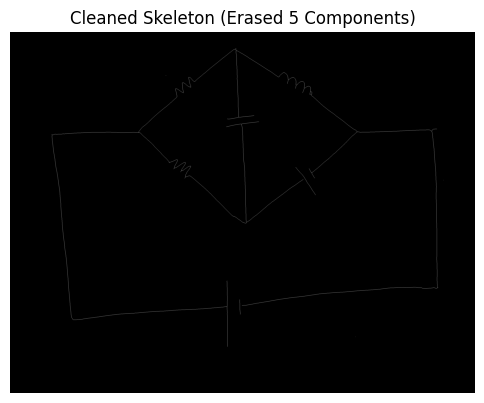

In [9]:
# ---------------- Erase class 0 regions from skeleton ----------------
label_path = "/Users/mac/Downloads/LineDetect/ImageData/otsu_thresholded.txt"

# Create a copy of skeleton to modify
skeleton_cleaned = skeleton.copy()
img_h, img_w = skeleton_cleaned.shape

# Read YOLO labels
with open(label_path, "r") as f:
    lines = [ln.strip() for ln in f.readlines() if ln.strip()]

erased_count = 0

for line in lines:
    parts = line.split()
    if len(parts) < 5:
        continue
    
    class_id = int(parts[0])
    
    # Only erase class 0 (Component) regions
    if class_id == 0:
        x_center = float(parts[1])
        y_center = float(parts[2])
        box_w = float(parts[3])
        box_h = float(parts[4])
        
        # Convert normalized coords to pixel coords
        x1 = int((x_center - box_w / 2) * img_w)
        y1 = int((y_center - box_h / 2) * img_h)
        x2 = int((x_center + box_w / 2) * img_w)
        y2 = int((y_center + box_h / 2) * img_h)
        
        # Clip to image bounds
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(img_w, x2), min(img_h, y2)
        
        # Erase the region (set to False/0)
        skeleton_cleaned[y1:y2, x1:x2] = False
        erased_count += 1

print(f"Erased {erased_count} class 0 (Component) regions from skeleton")

# Display cleaned skeleton
plt.figure(figsize=(6,6))
plt.imshow(skeleton_cleaned, cmap="gray")
plt.title(f"Cleaned Skeleton (Erased {erased_count} Components)")
plt.axis("off")
plt.show()

# Update the skeleton variable for subsequent cells
skeleton = skeleton_cleaned

In [10]:
img = skeleton.astype(np.uint8) * 255

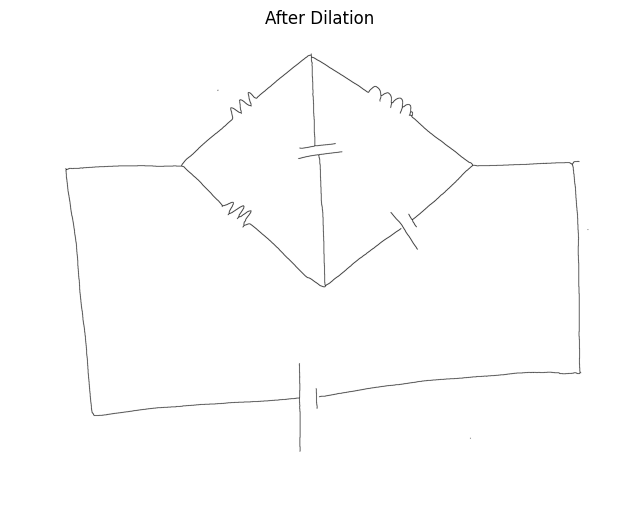

In [11]:
# invert so foreground becomes white for dilation
# inv = cv2.bitwise_not(img)
kernel = np.ones((3, 3), np.uint8)
dilated_inv = cv2.dilate(img, kernel, iterations=1)

# invert back
dilated = cv2.bitwise_not(dilated_inv)

plt.figure(figsize=(8,8))
plt.imshow(dilated, cmap="gray", vmin=0, vmax=255)
plt.title("After Dilation")
plt.axis("off")
plt.show()


Foreground pixels: 40517
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


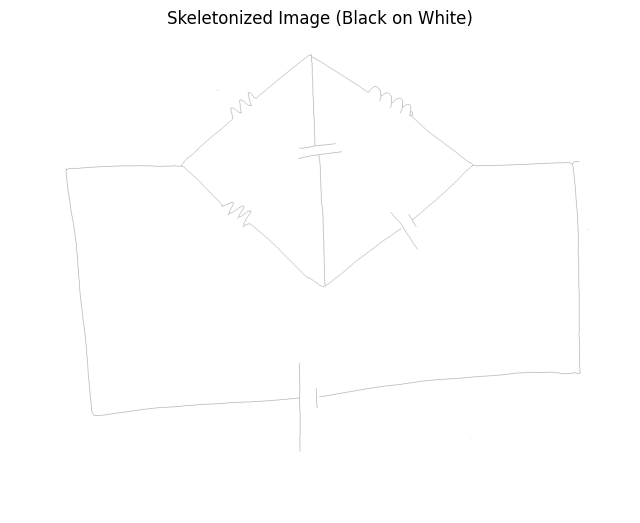

Skeleton image saved to skeleton_black_on_white.png


/Users/mac/Downloads/LineDetect/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: skeleton_black_on_white.png is a low contrast image
  return func(*args, **kwargs)


In [12]:
from skimage.io import imsave

# Foreground = black pixels
binary = (dilated < 128).astype(np.uint8)   # 1 where black line exists

print("Foreground pixels:", np.sum(binary))

skel = skeletonize(binary).astype(np.uint8)
skel_u8 = img_as_ubyte(skel)

# Convert to black skeleton on white background for display
skel_black_on_white = np.ones_like(dilated) * 255
skel_black_on_white[skel_u8 > 0] = 0
print(skel)

plt.figure(figsize=(8,8))
plt.imshow(skel_black_on_white, cmap="gray", vmin=0, vmax=255)
plt.title("Skeletonized Image (Black on White)")
plt.axis("off")
plt.show()


output_path = "skeleton_black_on_white.png"
imsave(output_path, skel_black_on_white.astype(np.uint8))

print(f"Skeleton image saved to {output_path}")

In [13]:
img = cv2.imread("skeleton_black_on_white.png", cv2.IMREAD_GRAYSCALE)

print(img.shape, img.dtype)

(2346, 3021) uint8


{'id': 1, 'conf': 0.698688, 'bbox_xyxy': (1431, 86, 1497, 152), 'endpoint_xy': (1464, 117), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.719609, 'bbox_xyxy': (1497, 1208, 1563, 1270), 'endpoint_xy': (1535, 1236), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.737837, 'bbox_xyxy': (2229, 625, 2281, 676), 'endpoint_xy': (2253, 650), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.746674, 'bbox_xyxy': (2706, 603, 2784, 681), 'endpoint_xy': (2744, 642), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.749698, 'bbox_xyxy': (813, 621, 867, 675), 'endpoint_xy': (839, 648), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.760988, 'bbox_xyxy': (239, 634, 312, 706), 'endpoint_xy': (274, 672), 'method': 'cls1_center_snap_closest'}
{'id': 8, 'conf': 0.761455, 'bbox_xyxy': (1375, 1588, 1530, 2058), 'endpoint1_xy': (1531, 1777), 'endpoint2_xy': (1374, 1789), 'method': 'border_hits_farthest_pair'}
{'id': 1, 'conf': 0.787298, 'bbox_xyxy': (2738, 1617

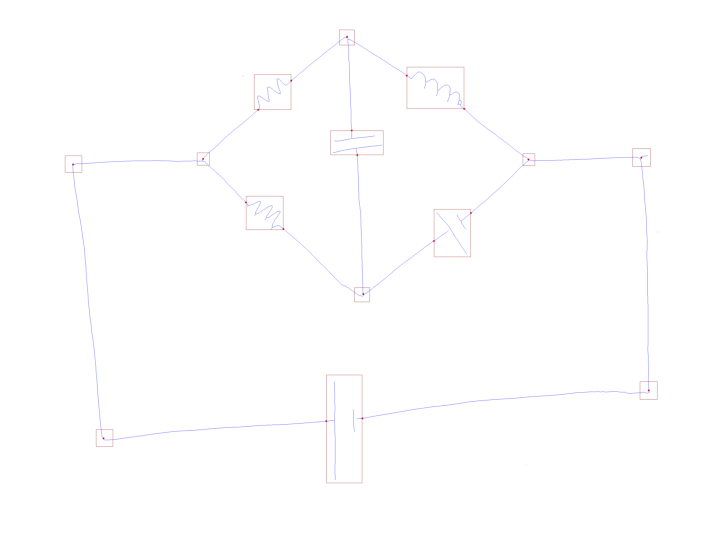

In [14]:
import numpy as np
import cv2
from skimage.morphology import skeletonize

# ---------------- IO helpers ----------------
def load_yolo_detections(txt_path):
    """
    Each line: cls xc yc w h conf   (all normalized except cls/conf)
    """
    dets = []
    with open(txt_path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            parts = line.strip().split()
            cls = int(parts[0])
            xc, yc, w, h = map(float, parts[1:5])
            conf = float(parts[5]) if len(parts) > 5 else None
            dets.append((cls, xc, yc, w, h, conf))
    return dets

def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = int(round((xc - w/2) * W))
    y1 = int(round((yc - h/2) * H))
    x2 = int(round((xc + w/2) * W))
    y2 = int(round((yc + h/2) * H))
    x1 = max(0, min(W-1, x1))
    y1 = max(0, min(H-1, y1))
    x2 = max(0, min(W-1, x2))
    y2 = max(0, min(H-1, y2))
    if x2 < x1: x1, x2 = x2, x1
    if y2 < y1: y1, y2 = y2, y1
    return x1, y1, x2, y2

# ---------------- Skeleton / geometry helpers ----------------
_NEIGH8 = [(-1,-1), (-1,0), (-1,1),
           ( 0,-1),         ( 0,1),
           ( 1,-1), ( 1,0), ( 1,1)]

def count_neighbors(skel, y, x):
    H, W = skel.shape
    c = 0
    for dy, dx in _NEIGH8:
        yy, xx = y+dy, x+dx
        if 0 <= yy < H and 0 <= xx < W and skel[yy, xx]:
            c += 1
    return c

def farthest_pair(points_xy):
    """
    points_xy: (N,2) array of (x,y)
    returns (p1, p2) as arrays (2,)
    """
    if points_xy is None or len(points_xy) == 0:
        return None
    if len(points_xy) == 1:
        return points_xy[0], points_xy[0]
    diff = points_xy[:, None, :] - points_xy[None, :, :]
    d2 = (diff**2).sum(axis=2)
    i, j = np.unravel_index(np.argmax(d2), d2.shape)
    return points_xy[i], points_xy[j]

def skeleton_intersections_with_bbox_border(skel, x1, y1, x2, y2, tol=1):
    """
    Return skeleton pixels that lie on/near the bbox border (within tol pixels).
    """
    H, W = skel.shape
    xx1 = max(0, x1 - tol); yy1 = max(0, y1 - tol)
    xx2 = min(W-1, x2 + tol); yy2 = min(H-1, y2 + tol)

    band = np.zeros_like(skel, dtype=bool)
    band[yy1:yy2+1, xx1:xx2+1] = True

    # carve out interior (keep only border band)
    if (x2 - x1) > 2*tol and (y2 - y1) > 2*tol:
        band[y1+tol:y2-tol+1, x1+tol:x2-tol+1] = False

    ys, xs = np.where((skel > 0) & band)
    if len(xs) == 0:
        return np.empty((0,2), dtype=int)
    return np.stack([xs, ys], axis=1)

def reduce_border_hits_to_two_endpoints(skel, inter_xy):
    """
    inter_xy: (N,2) array of (x,y) skeleton pixels near bbox border.
    Choose 2 endpoints robustly (can be 2+ points).
    """
    if len(inter_xy) == 0:
        return None, None, "no_border_hits"

    # Prefer true endpoints among border hits (degree==1)
    eps = []
    for x, y in inter_xy:
        if count_neighbors(skel, y, x) == 1:
            eps.append((x, y))
    eps = np.array(eps, dtype=int)

    if len(eps) >= 2:
        p1, p2 = farthest_pair(eps)
        return tuple(map(int, p1)), tuple(map(int, p2)), "border_hits_endpoint_degree1"
    else:
        p1, p2 = farthest_pair(inter_xy)
        return tuple(map(int, p1)), tuple(map(int, p2)), "border_hits_farthest_pair"

# ---------------- Class 1 (single endpoint) helpers ----------------
def nearest_skeleton_point_with_dist(skel, anchor_xy, search_xyxy):
    """
    Find nearest skeleton pixel to anchor_xy within search box.
    Returns (point_xy, squared_distance) or (None, None).
    """
    x1,y1,x2,y2 = search_xyxy
    roi = skel[y1:y2+1, x1:x2+1]
    ys, xs = np.where(roi > 0)
    if len(xs) == 0:
        return None, None

    pts = np.stack([x1+xs, y1+ys], axis=1)  # (N,2)
    ax, ay = anchor_xy
    d2 = (pts[:,0]-ax)**2 + (pts[:,1]-ay)**2
    i = int(np.argmin(d2))
    return tuple(map(int, pts[i])), float(d2[i])

def endpoint_for_class1_single(skel, x1, y1, x2, y2, margin=8):
    """
    Return ONE point for cls==1:
    - Take center of bbox
    - Find closest skeleton pixel to that center (within bbox expanded by margin)
    - Return (point_xy, method) in same format as before
    """
    H, W = skel.shape
    xc = int(round((x1 + x2) / 2))
    yc = int(round((y1 + y2) / 2))

    # expand search region to allow snapping just outside bbox
    sx1 = max(0, x1 - margin); sy1 = max(0, y1 - margin)
    sx2 = min(W - 1, x2 + margin); sy2 = min(H - 1, y2 + margin)

    p, d2 = nearest_skeleton_point_with_dist(skel, (xc, yc), (sx1, sy1, sx2, sy2))
    if p is None:
        return None, "cls1_no_skeleton_found"

    return p, "cls1_center_snap_closest"


# ---------------- Main pipeline ----------------
def detect_endpoints(image_path, txt_path, thresh=128, border_tol=1, cls1_margin=8):
    """
    - Builds skeleton from image (black pixels are foreground)
    - For cls==1: returns ONE endpoint (snapped to skeleton)
    - For cls!=0 and cls!=1: returns TWO endpoints using bbox-border intersections
    """
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    H, W = gray.shape

    binary = (gray < thresh).astype(np.uint8)
    skel = skeletonize(binary.astype(bool)).astype(np.uint8)

    dets = load_yolo_detections(txt_path)
    results = []

    for cls, xc, yc, w, h, conf in dets:
        if cls == 0:
            continue  # skip 0 as requested

        x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, W, H)

        if cls == 1:
            ep, method = endpoint_for_class1_single(skel, x1, y1, x2, y2, margin=cls1_margin)
            results.append({
                "id": cls,
                "conf": conf,
                "bbox_xyxy": (x1, y1, x2, y2),
                "endpoint_xy": ep,
                "method": method
            })
        else:
            inter = skeleton_intersections_with_bbox_border(skel, x1, y1, x2, y2, tol=border_tol)

            if len(inter) == 0:
                # fallback: use farthest pair of all skeleton pixels inside bbox
                roi = skel[y1:y2+1, x1:x2+1]
                ys, xs = np.where(roi > 0)
                pts = np.stack([x1+xs, y1+ys], axis=1) if len(xs) else np.empty((0,2), dtype=int)
                fp = farthest_pair(pts)
                if fp is None:
                    p1 = p2 = None
                    method = "bbox_no_border_hit_no_skeleton"
                else:
                    p1, p2 = tuple(map(int, fp[0])), tuple(map(int, fp[1]))
                    method = "bbox_no_border_hit_fallback_farthest_in_bbox"
            else:
                p1, p2, method = reduce_border_hits_to_two_endpoints(skel, inter)

            results.append({
                "id": cls,
                "conf": conf,
                "bbox_xyxy": (x1, y1, x2, y2),
                "endpoint1_xy": p1,
                "endpoint2_xy": p2,
                "method": method
            })

    return results, skel

# ---------------- Optional visualization ----------------
def visualize_results(image_path, results, skel=None, draw_skeleton=False):
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    for r in results:
        x1,y1,x2,y2 = r["bbox_xyxy"]
        cv2.rectangle(vis, (x1,y1), (x2,y2), (0,0,139), 1)

        if "endpoint_xy" in r:
            p = r["endpoint_xy"]
            if p is not None:
                cv2.circle(vis, p, 4, (0,0,255), -1)
        else:
            for k in ["endpoint1_xy", "endpoint2_xy"]:
                p = r.get(k, None)
                if p is not None:
                    cv2.circle(vis, p, 4, (0,0,255), -1)

    if draw_skeleton and skel is not None:
        ys, xs = np.where(skel > 0)
        vis[ys, xs] = (255, 0, 0)

    plt.figure(figsize=(12,7))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


# ---------------- Example usage ----------------
image_path = "/Users/mac/Downloads/LineDetect/skeleton_black_on_white.png"  # <-- set this
txt_path = "/Users/mac/Downloads/LineDetect/ImageData/otsu_thresholded.txt"

results, skel = detect_endpoints(
    image_path=image_path,
    txt_path=txt_path,
    thresh=128,
    border_tol=1,
    cls1_margin=8
)

for r in results:
    print(r)

visualize_results(image_path, results, draw_skeleton=True, skel=skel)



In [15]:
def extract_all_endpoints(results):
    """
    Extract all unique endpoints from results.
    Returns a list of (x, y) tuples.
    """
    endpoints = []
    for r in results:
        if "endpoint_xy" in r and r["endpoint_xy"] is not None:
            endpoints.append(r["endpoint_xy"])
        if "endpoint1_xy" in r and r["endpoint1_xy"] is not None:
            endpoints.append(r["endpoint1_xy"])
        if "endpoint2_xy" in r and r["endpoint2_xy"] is not None:
            endpoints.append(r["endpoint2_xy"])
    # Remove duplicates while preserving order
    seen = set()
    unique = []
    for ep in endpoints:
        if ep not in seen:
            seen.add(ep)
            unique.append(ep)
    return unique

In [16]:

def visualize_results_and_save(
    image_path,
    results,
    output_path,
    skel=None,
    draw_skeleton=False
):
    import cv2
    import numpy as np

    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    for r in results:
        x1, y1, x2, y2 = r["bbox_xyxy"]
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 139), 1)

        if "endpoint_xy" in r:
            p = r["endpoint_xy"]
            if p is not None:
                cv2.circle(vis, p, 4, (0, 0, 255), -1)
        else:
            for k in ["endpoint1_xy", "endpoint2_xy"]:
                p = r.get(k)
                if p is not None:
                    cv2.circle(vis, p, 4, (0, 0, 255), -1)

    if draw_skeleton and skel is not None:
        ys, xs = np.where(skel > 0)
        vis[ys, xs] = (255, 0, 0)

    # ---- SAVE AS PNG ----
    cv2.imwrite(output_path, vis)
    print(f"Saved visualization to: {output_path}")

output_png = "/Users/mac/Downloads/LineDetect/output_visualization.png"

visualize_results_and_save(
    image_path=image_path,
    results=results,
    output_path=output_png,
    draw_skeleton=True,
    skel=skel
)


Saved visualization to: /Users/mac/Downloads/LineDetect/output_visualization.png


In [17]:
results

[{'id': 1,
  'conf': 0.698688,
  'bbox_xyxy': (1431, 86, 1497, 152),
  'endpoint_xy': (1464, 117),
  'method': 'cls1_center_snap_closest'},
 {'id': 1,
  'conf': 0.719609,
  'bbox_xyxy': (1497, 1208, 1563, 1270),
  'endpoint_xy': (1535, 1236),
  'method': 'cls1_center_snap_closest'},
 {'id': 1,
  'conf': 0.737837,
  'bbox_xyxy': (2229, 625, 2281, 676),
  'endpoint_xy': (2253, 650),
  'method': 'cls1_center_snap_closest'},
 {'id': 1,
  'conf': 0.746674,
  'bbox_xyxy': (2706, 603, 2784, 681),
  'endpoint_xy': (2744, 642),
  'method': 'cls1_center_snap_closest'},
 {'id': 1,
  'conf': 0.749698,
  'bbox_xyxy': (813, 621, 867, 675),
  'endpoint_xy': (839, 648),
  'method': 'cls1_center_snap_closest'},
 {'id': 1,
  'conf': 0.760988,
  'bbox_xyxy': (239, 634, 312, 706),
  'endpoint_xy': (274, 672),
  'method': 'cls1_center_snap_closest'},
 {'id': 8,
  'conf': 0.761455,
  'bbox_xyxy': (1375, 1588, 1530, 2058),
  'endpoint1_xy': (1531, 1777),
  'endpoint2_xy': (1374, 1789),
  'method': 'border_hi

In [18]:
arrayendpoints2 = extract_all_endpoints(results)
print("All extracted endpoints:", arrayendpoints2)

All extracted endpoints: [(1464, 117), (1535, 1236), (2253, 650), (2744, 642), (839, 648), (274, 672), (1531, 1777), (1374, 1789), (2776, 1655), (406, 1864), (1724, 285), (1974, 430), (1222, 307), (1078, 434), (2003, 883), (1842, 1005), (1485, 524), (1509, 631), (1025, 837), (1188, 953)]


In [19]:
endpoints_only = [
    (r["endpoint1_xy"], r["endpoint2_xy"])
    for r in results
    if "endpoint1_xy" in r and "endpoint2_xy" in r
]
print("Extracted endpoint pairs for cls!=1:", endpoints_only)

Extracted endpoint pairs for cls!=1: [((1531, 1777), (1374, 1789)), ((1724, 285), (1974, 430)), ((1222, 307), (1078, 434)), ((2003, 883), (1842, 1005)), ((1485, 524), (1509, 631)), ((1025, 837), (1188, 953))]


In [20]:
from collections import deque
import numpy as np

# ---------------- Helpers ----------------

def get_neighbors8(y, x, H, W):
    """Return list of valid 8-connected neighbor coordinates (y, x)."""
    neighbors = []
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            if dy == 0 and dx == 0:
                continue
            ny, nx = y + dy, x + dx
            if 0 <= ny < H and 0 <= nx < W:
                neighbors.append((ny, nx))
    return neighbors

def disk_mask(radius):
    """
    Return a list of (dy, dx) offsets for a filled disk of given radius.
    Includes center (0,0).
    """
    offsets = []
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            if dy * dy + dx * dx <= radius * radius:
                offsets.append((dy, dx))
    return offsets

def build_node_id_map(skel, nodes, radius=20):
    """
    Build a node_id_map image where each pixel is:
      - node index i if within radius of node i
      - -1 otherwise
    
    Args:
        skel: (H, W) skeleton array
        nodes: list of (x, y) node coordinates
        radius: disk radius around each node
    
    Returns:
        node_id_map: (H, W) int array, -1 for non-node pixels
    """
    H, W = skel.shape
    node_id_map = np.full((H, W), -1, dtype=np.int32)
    
    disk = disk_mask(radius)
    
    for i, (nx, ny) in enumerate(nodes):
        for dy, dx in disk:
            py, px = ny + dy, nx + dx
            if 0 <= py < H and 0 <= px < W:
                node_id_map[py, px] = i
    
    return node_id_map

def bfs_neighbors_for_node(node_idx, nodes, skel, node_id_map, radius=20):
    """
    BFS from node node_idx along skeleton pixels.
    Stop each branch when hitting another node.
    
    Returns:
        set of neighbor node indices
    """
    H, W = skel.shape
    nx, ny = nodes[node_idx]
    
    neighbors_found = set()
    
    # Visited array for this BFS (pixel-level)
    visited = np.zeros((H, W), dtype=bool)
    
    # Mark the starting node's disk region as visited (to avoid self-hits)
    disk = disk_mask(radius)
    for dy, dx in disk:
        py, px = ny + dy, nx + dx
        if 0 <= py < H and 0 <= px < W:
            visited[py, px] = True
    
    # Initialize queue with skeleton pixels at the edge of the node's disk
    # These are pixels adjacent to the disk that are on the skeleton
    queue = deque()
    
    for dy, dx in disk:
        py, px = ny + dy, nx + dx
        if 0 <= py < H and 0 <= px < W:
            # Check 8-neighbors of this disk pixel
            for npy, npx in get_neighbors8(py, px, H, W):
                if not visited[npy, npx] and skel[npy, npx] > 0:
                    visited[npy, npx] = True
                    queue.append((npy, npx))
    
    # BFS
    while queue:
        cy, cx = queue.popleft()
        
        # Check if this pixel is part of another node
        other_node = node_id_map[cy, cx]
        if other_node != -1 and other_node != node_idx:
            # Found a neighbor node - record it and stop this branch
            neighbors_found.add(other_node)
            continue  # Do NOT enqueue neighbors from this pixel
        
        # Continue BFS: enqueue skeleton neighbors
        for npy, npx in get_neighbors8(cy, cx, H, W):
            if not visited[npy, npx] and skel[npy, npx] > 0:
                visited[npy, npx] = True
                queue.append((npy, npx))
    
    return neighbors_found

def build_adjacency(skel, nodes, radius=20):
    """
    Build adjacency dict from skeleton and node list.
    
    Args:
        skel: (H, W) skeleton array
        nodes: list of (x, y) node coordinates
        radius: disk radius for node detection
    
    Returns:
        adjacency: dict[int, set[int]] - undirected graph adjacency
    """
    print(f"Building adjacency for {len(nodes)} nodes with radius={radius}...")
    
    # Build node_id_map
    node_id_map = build_node_id_map(skel, nodes, radius)
    
    # Initialize adjacency
    adjacency = {i: set() for i in range(len(nodes))}
    
    # BFS from each node
    for i in range(len(nodes)):
        neighbors = bfs_neighbors_for_node(i, nodes, skel, node_id_map, radius)
        for j in neighbors:
            adjacency[i].add(j)
            adjacency[j].add(i)  # Undirected
    
    return adjacency

# ---------------- Build adjacency ----------------
adjacency = build_adjacency(skel, arrayendpoints2, radius=20)

# ---------------- Print adjacency ----------------
print("\n=== Node Adjacency ===")
for i, neighbors in adjacency.items():
    node_coord = arrayendpoints2[i]
    neighbor_strs = [f"{j} {arrayendpoints2[j]}" for j in sorted(neighbors)]
    print(f"Node {i} {node_coord}: -> {neighbor_strs}")

print(f"\n=== Summary ===")
total_edges = sum(len(n) for n in adjacency.values()) // 2
print(f"Total nodes: {len(adjacency)}")
print(f"Total edges: {total_edges}")

# Check connectivity
from collections import deque as dq
def count_components(adj):
    visited = set()
    components = 0
    for start in adj:
        if start not in visited:
            components += 1
            q = dq([start])
            while q:
                node = q.popleft()
                if node in visited:
                    continue
                visited.add(node)
                for neighbor in adj[node]:
                    if neighbor not in visited:
                        q.append(neighbor)
    return components

num_components = count_components(adjacency)
print(f"Connected components: {num_components}")

Building adjacency for 20 nodes with radius=20...

=== Node Adjacency ===
Node 0 (1464, 117): -> ['10 (1724, 285)', '12 (1222, 307)', '16 (1485, 524)']
Node 1 (1535, 1236): -> ['15 (1842, 1005)', '17 (1509, 631)', '19 (1188, 953)']
Node 2 (2253, 650): -> ['3 (2744, 642)', '11 (1974, 430)', '14 (2003, 883)']
Node 3 (2744, 642): -> ['2 (2253, 650)', '8 (2776, 1655)']
Node 4 (839, 648): -> ['5 (274, 672)', '13 (1078, 434)', '18 (1025, 837)']
Node 5 (274, 672): -> ['4 (839, 648)', '9 (406, 1864)']
Node 6 (1531, 1777): -> ['8 (2776, 1655)']
Node 7 (1374, 1789): -> ['9 (406, 1864)']
Node 8 (2776, 1655): -> ['3 (2744, 642)', '6 (1531, 1777)']
Node 9 (406, 1864): -> ['5 (274, 672)', '7 (1374, 1789)']
Node 10 (1724, 285): -> ['0 (1464, 117)', '11 (1974, 430)']
Node 11 (1974, 430): -> ['2 (2253, 650)', '10 (1724, 285)']
Node 12 (1222, 307): -> ['0 (1464, 117)', '13 (1078, 434)']
Node 13 (1078, 434): -> ['4 (839, 648)', '12 (1222, 307)']
Node 14 (2003, 883): -> ['2 (2253, 650)']
Node 15 (1842, 10

In [21]:
# ... (Your previous code for build_adjacency and helpers) ...

# 1. Generate the initial adjacency list
adjacency = build_adjacency(skel, arrayendpoints2, radius=15) # Assuming you updated radius

# ---------------- NEW: Discard Specific Lines ----------------

# The list of edges to remove (pairs of coordinates)

def find_node_index(target_coord, all_nodes):
    """
    Finds the index of a coordinate in the node list.
    Returns -1 if not found.
    """
    # Try exact match first
    try:
        return all_nodes.index(target_coord)
    except ValueError:
        # Optional: Add a proximity check here if coordinates might be off by 1-2 pixels
        # For now, we assume strict matching as requested.
        return -1

print(f"\n--- filtering {len(endpoints_only)} specific connections ---")

for (p1, p2) in endpoints_only:
    # Find the indices in your main node list
    idx1 = find_node_index(p1, arrayendpoints2)
    idx2 = find_node_index(p2, arrayendpoints2)

    # Check validity
    if idx1 == -1:
        print(f"Warning: Coord {p1} not found in node list. Skipping.")
        continue
    if idx2 == -1:
        print(f"Warning: Coord {p2} not found in node list. Skipping.")
        continue

    # Remove the connection if it exists (undirected = remove from both sides)
    removed = False
    if idx2 in adjacency[idx1]:
        adjacency[idx1].remove(idx2)
        removed = True
    
    if idx1 in adjacency[idx2]:
        adjacency[idx2].remove(idx1)
        removed = True

    if removed:
        print(f"Removed connection: Node {idx1} {p1} <-> Node {idx2} {p2}")
    else:
        print(f"Connection not found (already clean): Node {idx1} {p1} <-> Node {idx2} {p2}")

# ---------------- End of Filtering ----------------

# Now proceed with your summary and component counting
print("\n=== Final Node Adjacency ===")
for i, neighbors in adjacency.items():
    node_coord = arrayendpoints2[i]
    neighbor_strs = [f"{j}" for j in sorted(neighbors)]
    print(f"Node {i} {node_coord}: -> {neighbor_strs}")

# ... (Rest of your summary code) ...

Building adjacency for 20 nodes with radius=15...

--- filtering 6 specific connections ---
Connection not found (already clean): Node 6 (1531, 1777) <-> Node 7 (1374, 1789)
Removed connection: Node 10 (1724, 285) <-> Node 11 (1974, 430)
Removed connection: Node 12 (1222, 307) <-> Node 13 (1078, 434)
Connection not found (already clean): Node 14 (2003, 883) <-> Node 15 (1842, 1005)
Connection not found (already clean): Node 16 (1485, 524) <-> Node 17 (1509, 631)
Removed connection: Node 18 (1025, 837) <-> Node 19 (1188, 953)

=== Final Node Adjacency ===
Node 0 (1464, 117): -> ['10', '12', '16']
Node 1 (1535, 1236): -> ['15', '17', '19']
Node 2 (2253, 650): -> ['3', '11', '14']
Node 3 (2744, 642): -> ['2', '8']
Node 4 (839, 648): -> ['5', '13', '18']
Node 5 (274, 672): -> ['4', '9']
Node 6 (1531, 1777): -> ['8']
Node 7 (1374, 1789): -> ['9']
Node 8 (2776, 1655): -> ['3', '6']
Node 9 (406, 1864): -> ['5', '7']
Node 10 (1724, 285): -> ['0']
Node 11 (1974, 430): -> ['2']
Node 12 (1222, 30

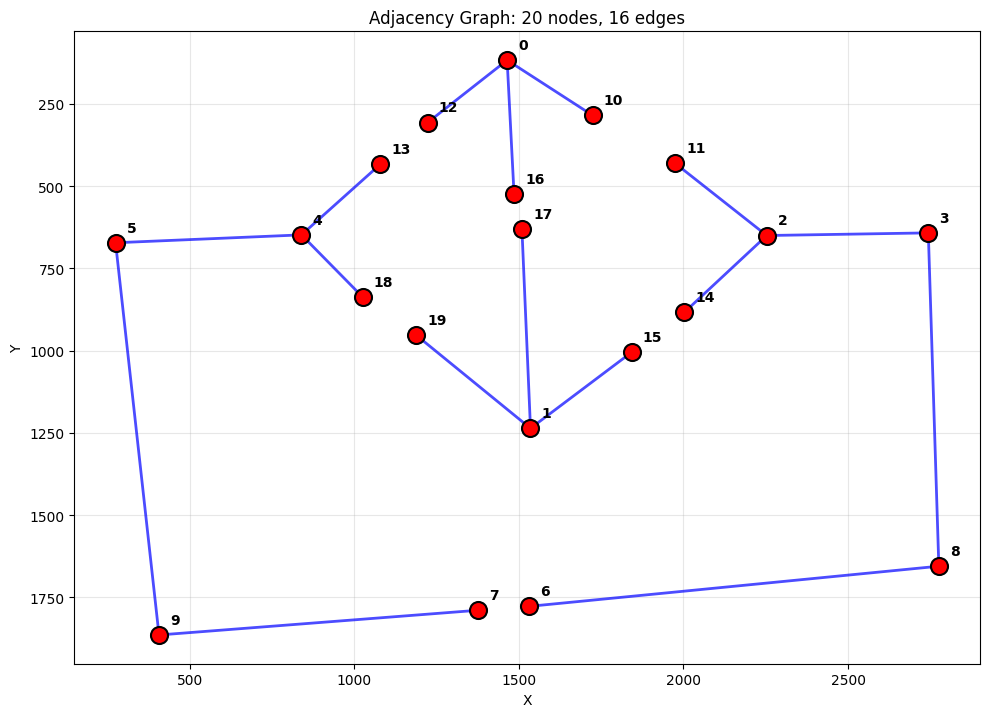

In [22]:
# ---------------- Visualize adjacency graph with raw lines ----------------
import matplotlib.pyplot as plt

def plot_adjacency_graph(nodes, adjacency, figsize=(10, 10)):
    """
    Plot the adjacency graph as raw lines on a blank canvas.
    
    Args:
        nodes: list of (x, y) node coordinates
        adjacency: dict[int, set[int]] adjacency
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Draw edges
    drawn_edges = set()
    for i, neighbors in adjacency.items():
        x1, y1 = nodes[i]
        for j in neighbors:
            # Avoid drawing same edge twice
            edge = tuple(sorted([i, j]))
            if edge in drawn_edges:
                continue
            drawn_edges.add(edge)
            
            x2, y2 = nodes[j]
            ax.plot([x1, x2], [y1, y2], 'b-', linewidth=2, alpha=0.7)
    
    # Draw nodes
    xs = [n[0] for n in nodes]
    ys = [n[1] for n in nodes]
    ax.scatter(xs, ys, s=150, c='red', zorder=5, edgecolors='black', linewidths=1.5)
    
    # Label nodes
    for i, (x, y) in enumerate(nodes):
        ax.annotate(str(i), (x, y), textcoords="offset points", 
                    xytext=(8, 8), fontsize=10, fontweight='bold')
    
    # Invert y-axis to match image coordinates (origin top-left)
    ax.invert_yaxis()
    
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Adjacency Graph: {len(nodes)} nodes, {len(drawn_edges)} edges')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot the adjacency graph
plot_adjacency_graph(arrayendpoints2, adjacency)

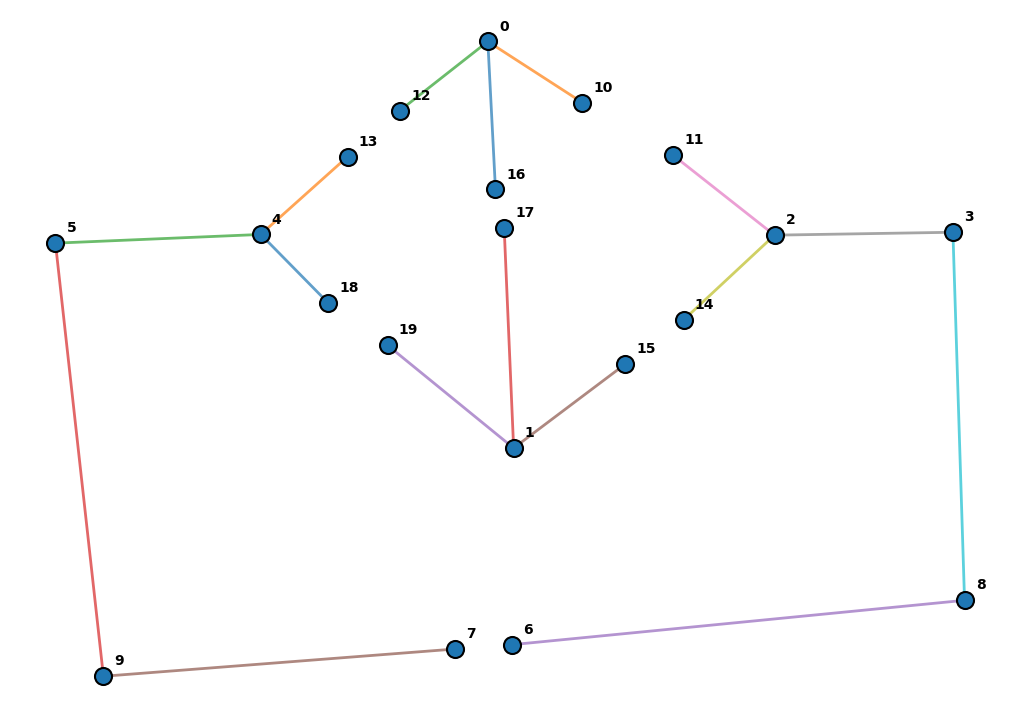

In [27]:
# ---------------- Visualize adjacency graph with raw lines ----------------
import matplotlib.pyplot as plt

def plot_adjacency_graph(nodes, adjacency, figsize=(10, 10)):
    """
    Plot the adjacency graph as raw lines on a plain white canvas.
    
    Args:
        nodes: list of (x, y) node coordinates
        adjacency: dict[int, set[int]] adjacency
    """
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    ax.set_facecolor('white')
    
    # Draw edges
    drawn_edges = set()
    for i, neighbors in adjacency.items():
        x1, y1 = nodes[i]
        for j in neighbors:
            edge = tuple(sorted([i, j]))
            if edge in drawn_edges:
                continue
            drawn_edges.add(edge)
            
            x2, y2 = nodes[j]
            ax.plot([x1, x2], [y1, y2], linewidth=2, alpha=0.7)
    
    # Draw nodes
    xs = [n[0] for n in nodes]
    ys = [n[1] for n in nodes]
    ax.scatter(xs, ys, s=150, zorder=5, edgecolors='black', linewidths=1.5)
    
    # Label nodes
    for i, (x, y) in enumerate(nodes):
        ax.annotate(
            str(i),
            (x, y),
            textcoords="offset points",
            xytext=(8, 8),
            fontsize=10,
            fontweight='bold'
        )
    
    # Invert y-axis to match image coordinates (origin top-left)
    ax.invert_yaxis()
    
    ax.set_aspect('equal')
    
    # Remove axes, grid, and frame
    ax.axis('off')
    ax.grid(False)
    
    plt.tight_layout(pad=0)
    plt.show()

# Plot the adjacency graph
plot_adjacency_graph(arrayendpoints2, adjacency)


In [23]:
import matplotlib.pyplot as plt

def plot_adjacency_graph(nodes, adjacency, figsize=(10, 10), out_svg=None):
    """
    Plot the adjacency graph as raw lines on a blank canvas.

    Args:
        nodes: list of (x, y) node coordinates
        adjacency: dict[int, set[int]] adjacency
        out_svg: if provided (str path), saves the plot as an SVG to this path
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Draw edges
    drawn_edges = set()
    for i, neighbors in adjacency.items():
        x1, y1 = nodes[i]
        for j in neighbors:
            edge = tuple(sorted((i, j)))
            if edge in drawn_edges:
                continue
            drawn_edges.add(edge)

            x2, y2 = nodes[j]
            ax.plot([x1, x2], [y1, y2], 'b-', linewidth=2, alpha=0.7)

    # Draw nodes
    xs = [n[0] for n in nodes]
    ys = [n[1] for n in nodes]
    ax.scatter(xs, ys, s=150, c='red', zorder=5, edgecolors='black', linewidths=1.5)

    # Label nodes
    for i, (x, y) in enumerate(nodes):
        ax.annotate(str(i), (x, y), textcoords="offset points",
                    xytext=(8, 8), fontsize=10, fontweight='bold')

    # Invert y-axis to match image coordinates (origin top-left)
    ax.invert_yaxis()

    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Adjacency Graph: {len(nodes)} nodes, {len(drawn_edges)} edges')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if out_svg:
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        plt.close(fig)  # prevents duplicate display in notebooks
    else:
        plt.show()

# Save as SVG
plot_adjacency_graph(arrayendpoints2, adjacency, out_svg="adjacency_graph.svg")


In [24]:
import matplotlib.pyplot as plt

def plot_adjacency_graph(nodes, adjacency, figsize=(10, 10), out_png=None):
    fig, ax = plt.subplots(figsize=figsize)

    # Draw edges
    drawn_edges = set()
    for i, neighbors in adjacency.items():
        x1, y1 = nodes[i]
        for j in neighbors:
            edge = tuple(sorted((i, j)))
            if edge in drawn_edges:
                continue
            drawn_edges.add(edge)

            x2, y2 = nodes[j]
            ax.plot([x1, x2], [y1, y2], 'b-', linewidth=2, alpha=0.7)

    # Draw nodes
    xs = [n[0] for n in nodes]
    ys = [n[1] for n in nodes]
    ax.scatter(xs, ys, s=150, c='red', zorder=5,
               edgecolors='black', linewidths=1.5)

    # Label nodes
    for i, (x, y) in enumerate(nodes):
        ax.annotate(str(i), (x, y),
                    textcoords="offset points",
                    xytext=(8, 8),
                    fontsize=10,
                    fontweight='bold')

    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Adjacency Graph: {len(nodes)} nodes, {len(drawn_edges)} edges')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if out_png:
        fig.savefig(out_png, dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

# Save as PNG
plot_adjacency_graph(arrayendpoints2, adjacency, out_png="adjacency_graph.png")


In [25]:
adjacency

{0: {np.int32(10), np.int32(12), np.int32(16)},
 1: {np.int32(15), np.int32(17), np.int32(19)},
 2: {np.int32(3), np.int32(11), np.int32(14)},
 3: {2, np.int32(8)},
 4: {np.int32(5), np.int32(13), np.int32(18)},
 5: {4, np.int32(9)},
 6: {np.int32(8)},
 7: {np.int32(9)},
 8: {3, 6},
 9: {5, 7},
 10: {0},
 11: {2},
 12: {0},
 13: {4},
 14: {2},
 15: {1},
 16: {0},
 17: {1},
 18: {4},
 19: {1}}

Found 19 bounding boxes


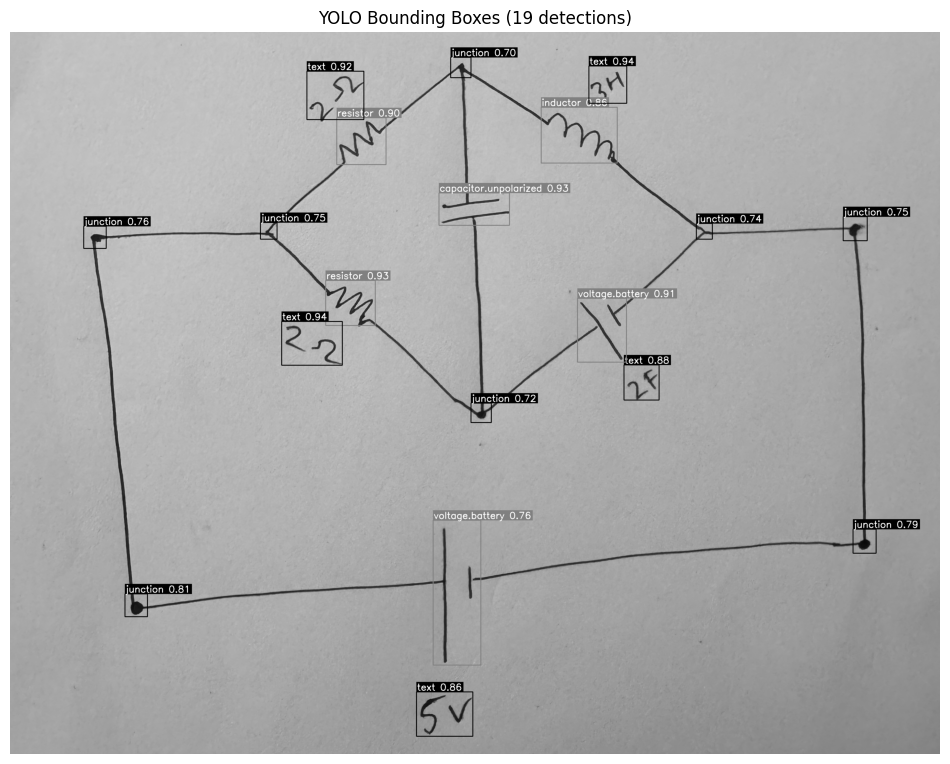


Detections by class:
  text (class 0): 5
  junction (class 1): 8
  voltage.battery (class 8): 2
  resistor (class 9): 2
  capacitor.unpolarized (class 12): 1
  inductor (class 15): 1


In [29]:
# ---------------- Draw YOLO bounding boxes on image ----------------
label_path = "/Users/mac/Downloads/LineDetect/ImageData/otsu_thresholded.txt"

# Read the image and convert to BGR for colored bounding boxes
# vis_img = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2BGR)
vis_img = skeleton.astype(np.uint8) * 255
img_h, img_w = skeleton.shape
vis_img=img.copy()


component_names = [
    "text",
    "junction",
    "crossover",
    "terminal",
    "gnd",
    "vss",
    "voltage.dc",
    "voltage.ac",
    "voltage.battery",
    "resistor",
    "resistor.adjustable",
    "resistor.photo",
    "capacitor.unpolarized",
    "capacitor.polarized",
    "capacitor.adjustable",
    "inductor",
    "inductor.ferrite",
    "inductor.coupled",
    "transformer",
    "diode",
    "diode.light_emitting",
    "diode.thyrector",
    "diode.zener",
    "diac",
    "triac",
    "thyristor",
    "varistor",
    "transistor.bjt",
    "transistor.fet",
    "transistor.photo",
    "operational_amplifier",
    "operational_amplifier.schmitt_trigger",
    "optocoupler",
    "integrated_circuit",
    "integrated_circuit.ne555",
    "integrated_circuit.voltage_regulator",
    "xor",
    "and",
    "or",
    "not",
    "nand",
    "nor",
    "probe",
    "probe.current",
    "probe.voltage",
    "switch",
    "relay",
    "socket",
    "fuse",
    "speaker",
    "motor",
    "lamp",
    "microphone",
    "antenna",
    "crystal",
    "magnetic",
    "mechanical",
    "block",
    "explanatory",
    "unknown"
]


# Define colors for different classes (BGR format)
class_colors = {
    0: (0, 0, 255),    # Green for class 0
    1: (0, 0, 255),    # Red for class 1
    2: (255, 0, 0),    # Blue for class 2
    3: (255, 255, 0),  # Cyan for class 3
    4: (255, 0, 255),  # Magenta for class 4
}

class_names = {i: name for i, name in enumerate(component_names)}

# Read YOLO labels and draw boxes
with open(label_path, "r") as f:
    lines = [ln.strip() for ln in f.readlines() if ln.strip()]

print(f"Found {len(lines)} bounding boxes")

for line in lines:
    parts = line.split()
    if len(parts) < 5:
        continue
    
    class_id = int(parts[0])
    x_center = float(parts[1])
    y_center = float(parts[2])
    box_w = float(parts[3])
    box_h = float(parts[4])
    conf = float(parts[5]) if len(parts) > 5 else None
    
    # Convert normalized coords to pixel coords
    x1 = int((x_center - box_w / 2) * img_w)
    y1 = int((y_center - box_h / 2) * img_h)
    x2 = int((x_center + box_w / 2) * img_w)
    y2 = int((y_center + box_h / 2) * img_h)
    
    # Clip to image bounds
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img_w, x2), min(img_h, y2)
    
    # Get color for this class
    color = class_colors.get(class_id, (128, 128, 128))
    
    # Draw rectangle
    cv2.rectangle(vis_img, (x1, y1), (x2, y2), color, 2)
    
    # Draw label
    label = class_names.get(class_id, f"Class {class_id}")
    if conf is not None:
        label = f"{label} {conf:.2f}"
    
    # Label background (larger font size: 1.0 instead of 0.5, thickness: 2 instead of 1)
    font_scale = 1.0
    font_thickness = 2
    (label_w, label_h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_thickness)
    cv2.rectangle(vis_img, (x1, y1 - label_h - 10), (x1 + label_w + 5, y1), color, -1)
    cv2.putText(vis_img, label, (x1 + 2, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), font_thickness)

# Display
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.title(f"YOLO Bounding Boxes ({len(lines)} detections)")
plt.axis("off")
plt.show()

# Count by class
from collections import Counter
class_counts = Counter(int(line.split()[0]) for line in lines if line.split())
print("\nDetections by class:")
for cls_id, count in sorted(class_counts.items()):
    name = class_names.get(cls_id, f"Class {cls_id}")
    print(f"  {name} (class {cls_id}): {count}")